# **TRABAJO PRÁCTICO N° 2**

# Predicción de lluvia en Australia 
---
##### 1er Cuatrimestre - Año 2026

| **Integrantes**           | **Legajo** |
|---------------------------|------------|
|Bartomioli Ornella         |(Dni) 47077671 |
| Stefano Candela           | S-5872/6   |
| Vera Nahir Sol            | V-3139/9   |


##### **Docentes:** 


Librerias:

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, mean_absolute_error,
                             mean_squared_error,classification_report,ConfusionMatrixDisplay,roc_curve, auc)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

import shap
import warnings 
from pycaret.regression import setup, compare_models, predict_model, save_model
from pycaret.classification import setup, compare_models, predict_model, save_model

# Entrega 1:

# 1) Carga y análisis de los datos.

In [2]:
# Carga y visuaización del conjunto de datos
lluvias = pd.read_csv('weatherAUS_2026C1.csv')
lluvias.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [3]:
lluvias = lluvias.rename(columns={
    'Unnamed: 0': 'id',
    'Date': 'fecha',
    'Location': 'ubicacion',
    'MinTemp': 'temp_min',
    'MaxTemp': 'temp_max',
    'Rainfall': 'lluvia',
    'Evaporation': 'evaporacion',
    'Sunshine': 'horas_sol',
    'WindGustDir': 'dir_rafaga_viento',
    'WindGustSpeed': 'vel_rafaga_viento',
    'WindDir9am': 'dir_viento_9am',
    'WindDir3pm': 'dir_viento_3pm',
    'WindSpeed9am': 'vel_viento_9am',
    'WindSpeed3pm': 'vel_viento_3pm',
    'Humidity9am': 'humedad_9am',
    'Humidity3pm': 'humedad_3pm',
    'Pressure9am': 'presion_9am',
    'Pressure3pm': 'presion_3pm',
    'Cloud9am': 'nubes_9am',
    'Cloud3pm': 'nubes_3pm',
    'Temp9am': 'temp_9am',
    'Temp3pm': 'temp_3pm',
    'RainToday': 'llovio_hoy',
    'RainTomorrow': 'llueve_manana',
    'RainfallTomorrow': 'lluvia_manana'})

lluvias.head()

,id,fecha,ubicacion,temp_min,temp_max,lluvia,evaporacion,horas_sol,dir_rafaga_viento,vel_rafaga_viento,...,humedad_3pm,presion_9am,presion_3pm,nubes_9am,nubes_3pm,temp_9am,temp_3pm,llovio_hoy,llueve_manana,lluvia_manana
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [4]:
lluvias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 145412 non-null  int64  
 1   fecha              145412 non-null  object 
 2   ubicacion          145412 non-null  object 
 3   temp_min           143928 non-null  float64
 4   temp_max           144159 non-null  float64
 5   lluvia             142152 non-null  float64
 6   evaporacion        82658 non-null   float64
 7   horas_sol          75616 non-null   float64
 8   dir_rafaga_viento  135096 non-null  object 
 9   vel_rafaga_viento  135159 non-null  float64
 10  dir_viento_9am     134850 non-null  object 
 11  dir_viento_3pm     141186 non-null  object 
 12  vel_viento_9am     143645 non-null  float64
 13  vel_viento_3pm     142351 non-null  float64
 14  humedad_9am        142759 non-null  float64
 15  humedad_3pm        140907 non-null  float64
 16  pr

In [5]:
# Tratamiendo variable 'Date'
lluvias['fecha'] = pd.to_datetime(lluvias['fecha'])
lluvias['mes'] = lluvias['fecha'].dt.month

lluvias = lluvias.drop(columns=['fecha'])

Se transformó la variable fecha a datetime para poder trabajar adecuadamente con ella y extraer la información correspondiente al mes de cada observación.

In [6]:
# Eliminación variable 'id'
lluvias = lluvias.drop(columns=['id'])

Se eliminó la variable id, ya que actúa únicamente como un identificador y no aporta información para el análisis.

 **Análisis de variables:**

In [7]:
lluvias.describe()

,temp_min,temp_max,lluvia,evaporacion,horas_sol,vel_rafaga_viento,vel_viento_9am,vel_viento_3pm,humedad_9am,humedad_3pm,presion_9am,presion_3pm,nubes_9am,nubes_3pm,temp_9am,temp_3pm,lluvia_manana,mes
count,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135159.000000,143645.000000,142351.000000,142759.000000,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000,142153.000000,145412.000000
mean,12.196528,23.223064,2.361516,5.468616,7.611241,40.036668,14.067277,18.661899,68.861521,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360,2.361242,6.399747
std,6.417956,7.135927,8.479338,4.193871,3.785612,13.648259,8.936768,8.865457,19.062866,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072,8.479084,3.427820
min,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,0.000000,1.000000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,12.000000,57.000000,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000,3.000000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,38.000000,13.000000,18.000000,69.900000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000,6.000000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000,9.000000
max,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,130.000000,86.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,9.000000,39.800000,47.000000,371.000000,12.000000


In [8]:
# Verificación de las localidades
ubicaciones = lluvias['ubicacion'].unique()
print(ubicaciones)

['Albury' 'BadgerysCreek' 'Cobar' 'CoffsHarbour' 'Moree' 'Newcastle'
 'NorahHead' 'NorfolkIsland' 'Penrith' 'Richmond' 'Sydney' 'SydneyAirport'
 'WaggaWagga' 'Williamtown' 'Wollongong' 'Canberra' 'Tuggeranong'
 'MountGinini' 'Ballarat' 'Bendigo' 'Sale' 'MelbourneAirport' 'Melbourne'
 'Mildura' 'Nhil' 'Portland' 'Watsonia' 'Dartmoor' 'Brisbane' 'Cairns'
 'GoldCoast' 'Townsville' 'Adelaide' 'MountGambier' 'Nuriootpa' 'Woomera'
 'Albany' 'Witchcliffe' 'PearceRAAF' 'PerthAirport' 'Perth' 'SalmonGums'
 'Walpole' 'Hobart' 'Launceston' 'AliceSprings' 'Darwin' 'Katherine'
 'Uluru']


Analizamos las ubicaciones registradas con el objetivo de verificar su correcta codificación y asegurar la ausencia de valores duplicados o inconsistencias en su representación.

In [9]:
# Valores posibles para llovio_hoy :
lluvias['llovio_hoy'].unique()

array(['No', 'Yes', nan], dtype=object)

In [10]:
# Valores posibles para llueve_manana :
lluvias['llueve_manana'].unique()

array(['No', 'Yes', nan], dtype=object)

In [11]:
lluvias['horas_sol'].value_counts().sort_index()

horas_sol
0.0     2359
0.1      542
0.2      521
0.3      433
0.4      326
        ... 
14.0      15
14.1       6
14.2       2
14.3       4
14.5       1
Name: count, Length: 145, dtype: int64

**Valores faltantes:**

**Variables temporales: Datetime y numéricas discretas.**

* fecha: fecha de la observación meteorológica. (2007-11-01 a 2017-06-24)
* dia: día de la semana de la observación. Valores del 1 (lunes) al 7 (domingo).
* mes: mes de la observación. Valores del 1 al 12.
* anio: año de la observación. Valores del 2007 al 2017.

**Variable de Ubicación: Categórica.**
* ubicacion: ciudad de Australia donde se registró el clima (49 ciudades distintas).

**Variables de temperatura: Numéricas continuas.**
* temp_min: temperatura mínima en el día en °C. (-9.7 a 34.1)
* temp_max: temperatura máxima en el día en °C. (-5.1 a 49.1)
* temp_9am: temperatura a las 9am en °C. (-8.0 a 39.8)
* temp_3pm: temperatura a las 3pm en °C. (-5.8 a 47.0)

**Variables de viento:
Categóricas:**
* dir_rafaga_viento: dirección de la ráfaga de viento más fuerte (16 direcciones).
* dir_viento_9am y dir_viento_3pm: dirección del viento a las 9am y 3pm (16 direcciones posibles).

**Numéricas continuas:**
* vel_viento_9am: velocidad del viento a las 9am en km/h. (0.0 a 130.0)
* vel_viento_3pm: velocidad del viento a las 3pm en km/h. (0.0 a 86.0)
* vel_rafaga_viento: velocidad de la ráfaga de viento máxima en km/h. (6.0 a 135.0)

**Variables de humedad y presión: Numéricas continuas.**
* humedad_9am y humedad_3pm: porcentaje de humedad a las 9am y 3pm. (0.0 a 100.0)
* presion_9am y presion_3pm: presión atmosférica medida en hPa a las 9am y 3pm. (980.3 a 1041.2) y (977.4 a 1039.8)

**Variables del clima: Numéricas continuas / discretas.**
* nubes_9am y nubes_3pm: nivel de nubosidad. (0.0 a 9.0)
* horas_sol: cantidad de horas de sol en el día. (0.0 a 14.5)
* evaporacion: nivel de evaporación aparente en mm. (0.0 a 145.0)
* lluvia: cantidad de agua caida acumulada durante el día en mm. (0.0 a 371.0)

**Variables de hecho (o categóricas de decisión):**
* llovio_hoy: variable categórica que indica si el día de hoy se superó 1 mm de lluvia. (No / Yes)
* llovera_manana: variable categórica objetivo que indica si lloverá al día siguiente. (No / Yes)
* lluvia_manana: cantidad de lluvia registrada al día siguiente en mm. (0.0 a 371.0)

In [12]:
# Eliminacion de las observaciones con la variable objetivo Nan:
lluvias = lluvias[lluvias['llueve_manana'].notna()]

Eliminamos los registros que no contaban con la variable a predecir.

In [13]:
# Cantidad de nulos por columna:
cant = lluvias.isnull().sum()

# Porcentaje de nulos por columna:
porc_nul = (lluvias.isnull().sum() / len(lluvias)) * 100 

tabla_nulos = pd.DataFrame({
    'Cantidad_nulos': cant,
    'Porcentaje_nulos': porc_nul})

# Ordenar
tabla_nulos = tabla_nulos.sort_values(by='Porcentaje_nulos', ascending=False)

tabla_nulos

,Cantidad_nulos,Porcentaje_nulos
horas_sol,67785,47.684537
evaporacion,60812,42.779259
nubes_3pm,57076,40.151105
nubes_9am,53641,37.734694
presion_9am,14010,9.855578
presion_3pm,13977,9.832364
dir_viento_9am,10009,7.041005
dir_rafaga_viento,9328,6.561944
vel_rafaga_viento,9268,6.519736
dir_viento_3pm,3776,2.656293


Se observa una gran cantidad de valores faltantes, luego de hacer la división train/test los trabajaremos.

In [14]:
# Lista de columnas donde decidimos eliminar las filas con nulos
col_nan = ['dir_viento_9am', 'dir_rafaga_viento', 'vel_rafaga_viento', 'humedad_3pm', 'dir_viento_3pm', 'temp_3pm', 'llovio_hoy', 
    'lluvia', 'llueve_manana', 'lluvia_manana', 'vel_viento_3pm', 'humedad_9am', 'vel_viento_9am', 'temp_9am', 'temp_min', 'temp_max']

cant = lluvias.shape[0]
lluvias = lluvias.dropna(subset=col_nan).copy()

print(f"Registros después de la limpieza: {lluvias.shape[0]} y Eliminados: {cant - lluvias.shape[0]}")

Registros después de la limpieza: 121757 y Eliminados: 20396


Eliminamos los registros co valores faltantes en las variables que presentaban menos proporción de Nan.

In [15]:
lluvias['llueve_manana'].value_counts(normalize=True) * 100

llueve_manana
No     77.923241
Yes    22.076759
Name: proportion, dtype: float64

El dataset no se encuentra balanceado, ya que predominan los registros correspondientes a días en los que no llueve. El desbalance de clases puede afectar el rendimiento del modelo de clasificación, provocando que tienda a predecir con mayor frecuencia la clase mayoritaria. Métricas como accuracy pueden resultar engañosas, por lo que es importante analizar también precisión, recall y matriz de confusión.

# 2) División conjuntos train y test.

In [16]:
# Separamos X e y:
X = lluvias.drop(['llueve_manana','lluvia_manana'], axis=1)
y = lluvias['llueve_manana']

In [17]:
# Dividir train y test:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

X_train = X_train.copy()
X_test = X_test.copy()

# 3) Limpieza y tratamiento.

### Tratamiento de valores faltantes:

In [18]:
# Cantidad de nulos por columna:
cant = lluvias.isnull().sum()

# Porcentaje de nulos por olumna:
porc_nul = (X_train.isnull().sum() / len(lluvias)) * 100 

tabla_nulos = pd.DataFrame({
    'Cantidad_nulos': cant,
    'Porcentaje_nulos': porc_nul
})

# Ordeanar
tabla_nulos = tabla_nulos.sort_values(by='Porcentaje_nulos', ascending=False)

tabla_nulos.head(7)

,Cantidad_nulos,Porcentaje_nulos
horas_sol,55045,36.149872
evaporacion,49877,32.786616
nubes_3pm,46727,30.724312
nubes_9am,45385,29.862759
presion_9am,8826,5.833751
presion_3pm,8775,5.796792
vel_viento_3pm,0,0.000000


Se decidió imputar los valores faltantes de las variables horas_sol, evaporación, nubes_3pm, nubes_9am, presion_9am y presion_3pm, ya que todas presentan mayor proporción de observaciones nulas. Utilizamos la media, considerando la ubicación y el mes como criterios de agrupación, con el objetivo representar la estacion y la geográfica de los datos.

Visualizamos las distribuciones de las vaiables que van a ser imptadas para verificar que al hacerlo no se altere su comportamiento original.

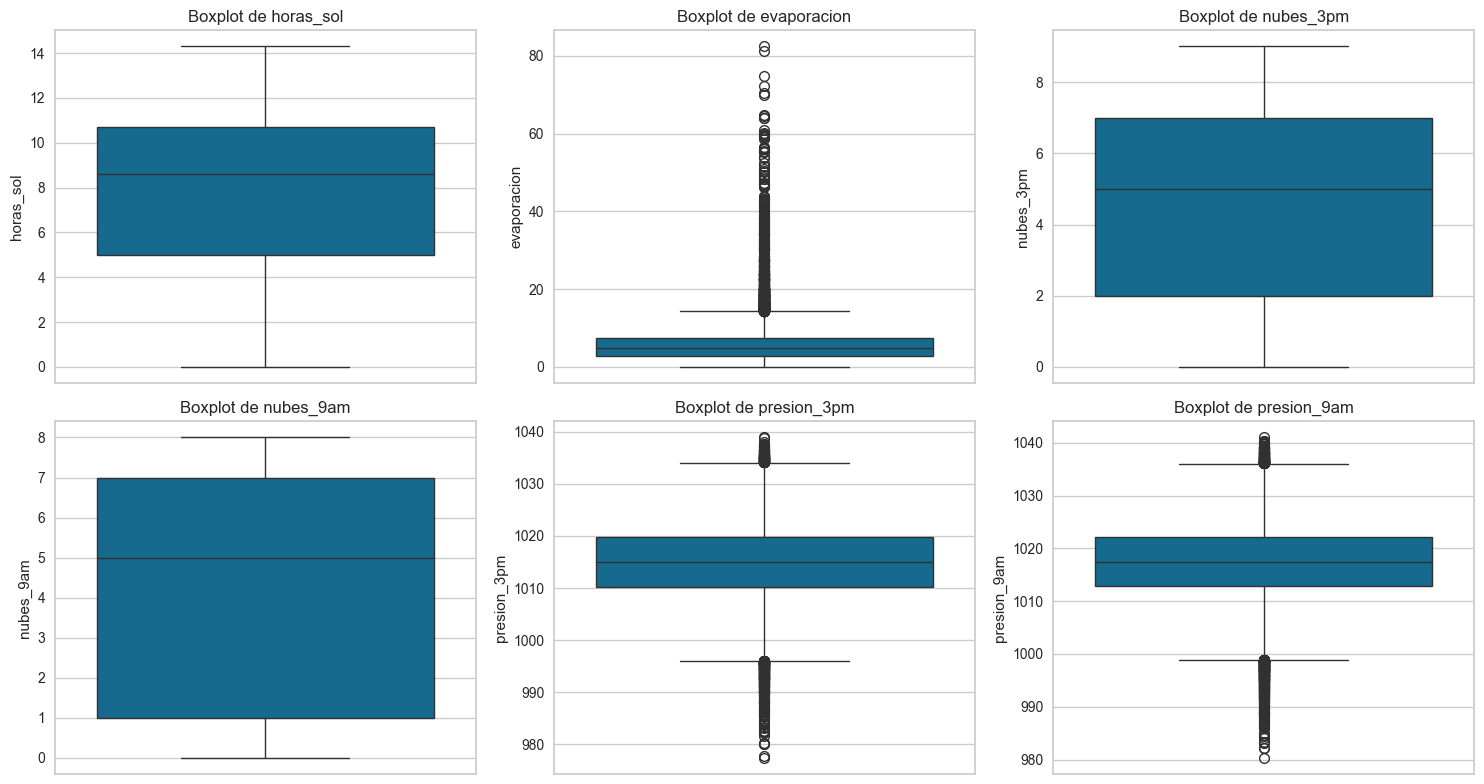

In [19]:
# BOXPLOTS
cols_num = ['horas_sol', 'evaporacion', 'nubes_3pm', 'nubes_9am', 'presion_3pm','presion_9am']

plt.figure(figsize=(15,8))

for i, col in enumerate(cols_num):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=X_train, y=col)
    plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

In [20]:
def imputar_por_ubi_y_mes(datos, columna):
    """
    Imputa valores nulos de una columna usando la media agrupada por ubicacion y mes.
    """

    datos[columna] =datos[columna].fillna( datos.groupby(['ubicacion', 'mes'])[columna].transform('mean'))

    # Caso de no tener registros para esa configuracion
    datos[columna] = datos[columna].fillna(datos[columna].mean())

    return datos


In [21]:
# Imputación X_train:
col_imputar = ['horas_sol','evaporacion','nubes_3pm','nubes_9am','presion_9am','presion_3pm']

for col in col_imputar:
    X_train = imputar_por_ubi_y_mes(X_train, col)

In [22]:
# Imputación X_test con los valores de X_train
for col in col_imputar:

    # medias del train
    medias_grupo = X_train.groupby(['ubicacion', 'mes'])[col].mean()
    media_global = X_train[col].mean()

    # imputación por grupo
    X_test[col] = X_test.apply(
        lambda row: medias_grupo.get((row['ubicacion'], row['mes']), None)
        if pd.isnull(row[col]) else row[col],
        axis=1)

    # imputación global
    X_test[col] = X_test[col].fillna(media_global)


### Análisis de distribuciones:

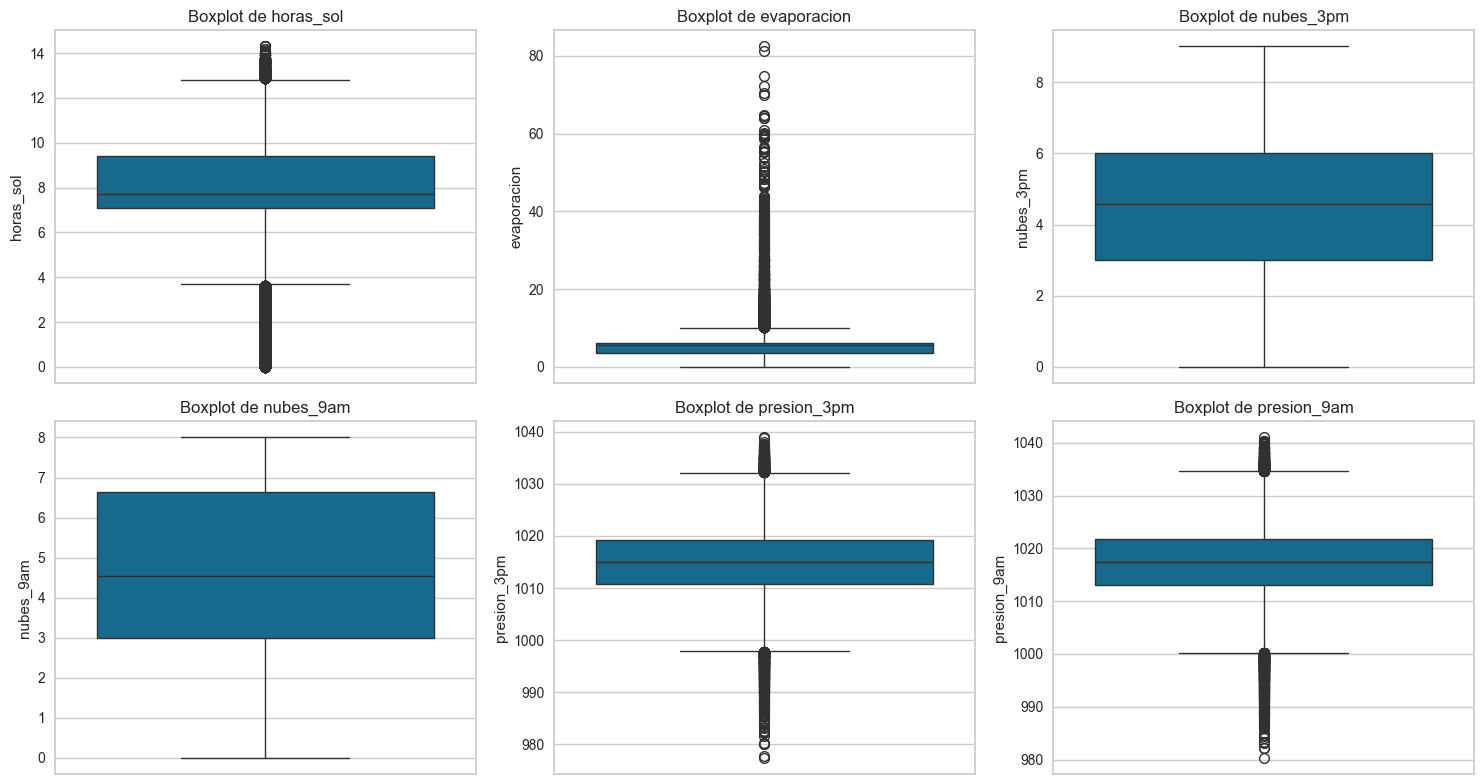

In [23]:
cols_num = ['horas_sol', 'evaporacion', 'nubes_3pm', 'nubes_9am', 'presion_3pm','presion_9am']

plt.figure(figsize=(15,8))

for i, col in enumerate(cols_num):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=X_train, y=col)
    plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

Al comparar las distribuciones antes y después de imputar por la media, observamos que la forma general de las variables se conserva, ya que las medianas y los rangos intercuartílicos no presentan cambios significativos. La imputación genera una mayor concentración de observaciones alrededor del valor medio y una reducción de la variabilidad. Si bien la presencia de valores atípicos podría afectar a la media y hacer que otras medidas resulten más robustas, decidimos mantener este criterio ya que no se observaron alteraciones importantes en la distribución ni en el comportamiento general de las variables.

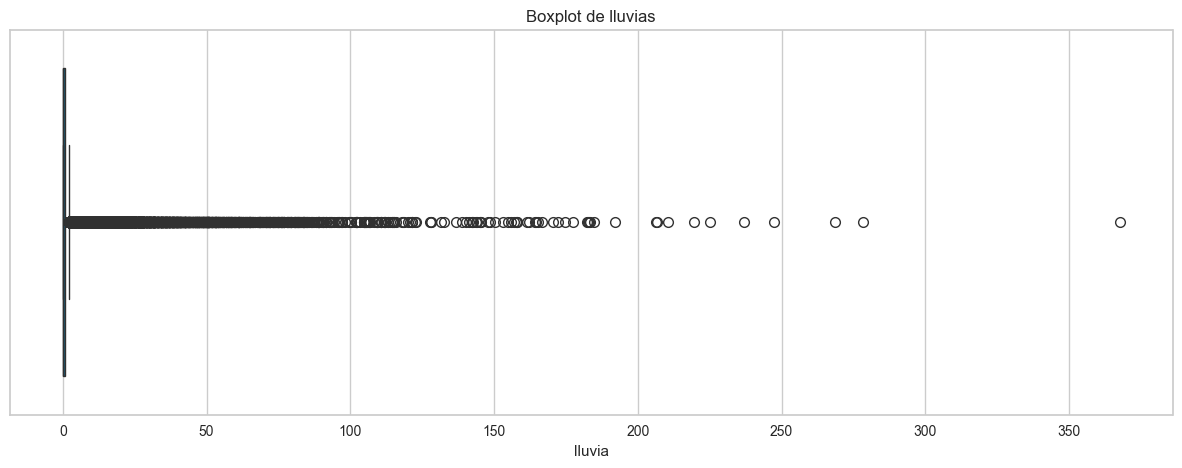

In [24]:
plt.figure(figsize=(15,5))
sns.boxplot(data=X_train, x='lluvia')
plt.title(f"Boxplot de lluvias")

plt.show()

Observamos una distribución asimetrica a la derecha. Como la mayoria de los días no llovió, se concentran los datos al principio del eje en el cero.

Los datos atipicos representan los días que si hubo precipitaciones. Como el cero es lo normal, cualquier dia con lluvias moderadas o tormentan se representan compo atipico.

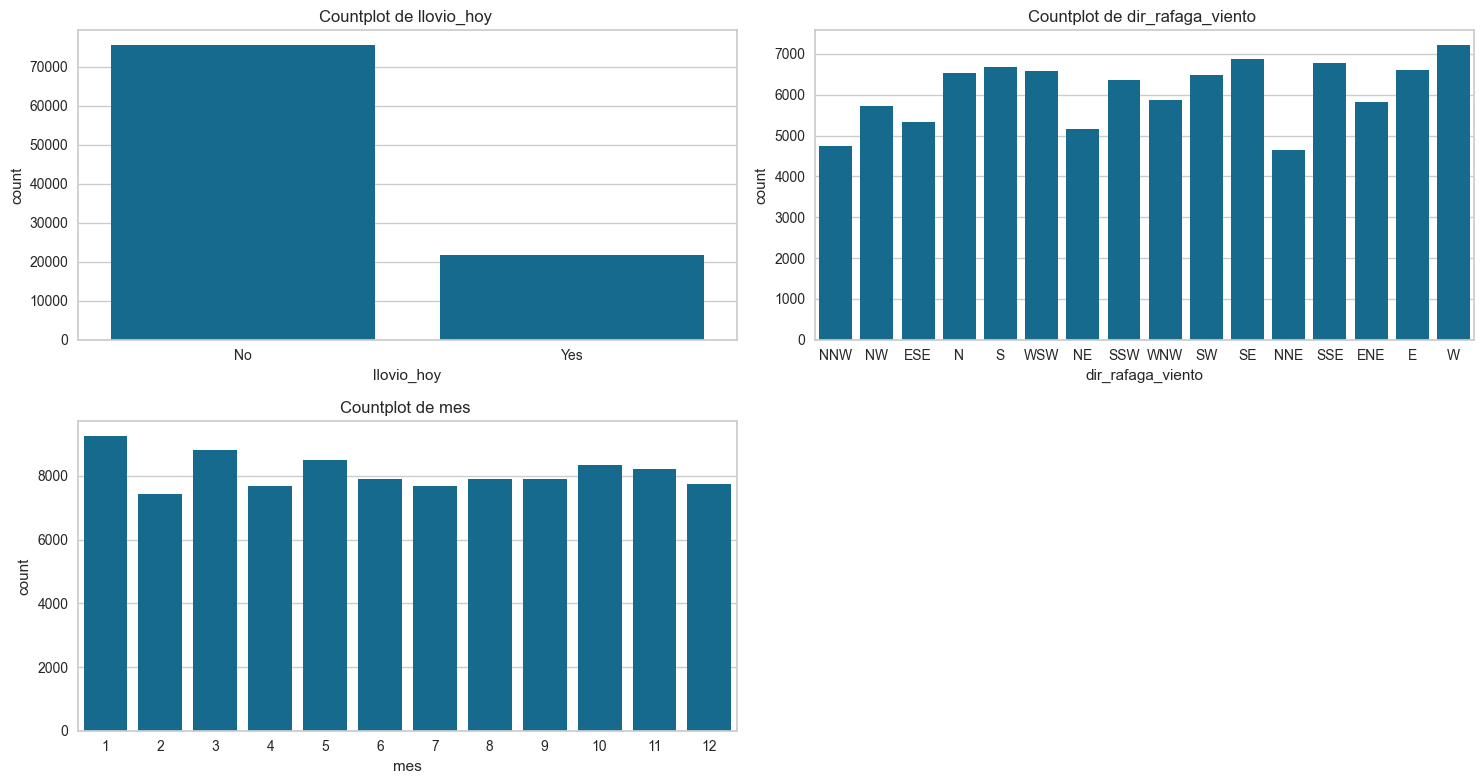

In [25]:
cols_cat = ['llovio_hoy','dir_rafaga_viento','mes']

plt.figure(figsize=(15,8))

for i, col in enumerate(cols_cat):
    plt.subplot(2, 2, i+1)
    sns.countplot(data=X_train, x=col)
    plt.title(f"Countplot de {col} ")

plt.tight_layout()
plt.show()

En base al countplot con las variables llovio_hoy, dir_rafaga_viento y mes, podemos observar:

Para la variable mes, las observaciones se distribuyen de manera uniforme a lo largo de los doce meses, dando a entender que existe la misma cantidad de datos para todas las estaciones climaticas sin sesgos temporales.

Para dir_rafaga_viento la distribución demuestra un comportamiento variado y bastante equilibrado entre los 16 puntos, lo que indica que no hay una unica direccion del viento que domine todo el dataset.

Por ultimo en llovio_hoy el grafico expone un fuerte desbalance de clases, evidenciando que en la gran mayoria de los dias registrados no hubo precipitaciones significativas.

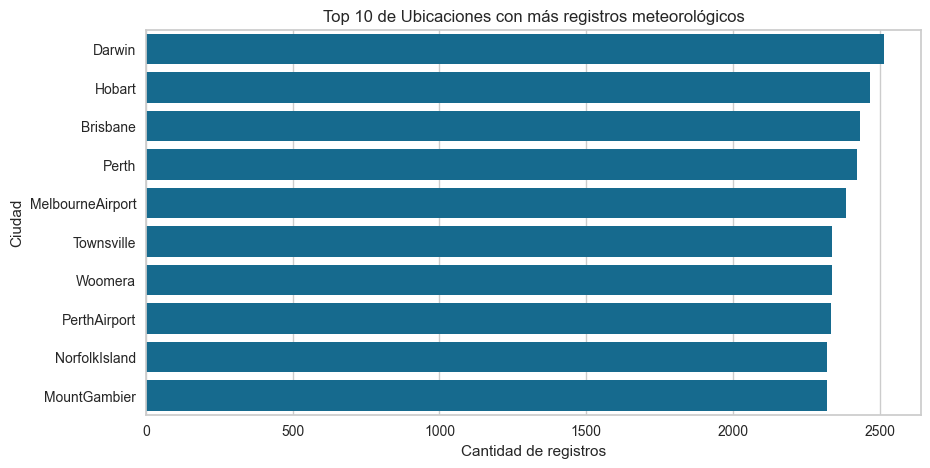

In [26]:
#  Countplot con el Top 10 de ubicaciones
plt.figure(figsize=(10, 5))

top_10_ubicaciones = X_train['ubicacion'].value_counts().head(10).index
sns.countplot(data=X_train, y='ubicacion', order=top_10_ubicaciones)

plt.title("Top 10 de Ubicaciones con más registros meteorológicos")
plt.xlabel("Cantidad de registros")
plt.ylabel("Ciudad")
plt.show()

Hacemos un countplot aparte con la variable ubicacion pues es categorica.

Podemos observar que el top 10 de las ubicaciones con mas registros estan dentro del intervalo de 2000 y 2500.

Siendo el top 1 Darwing y el top 10 MountGambier.

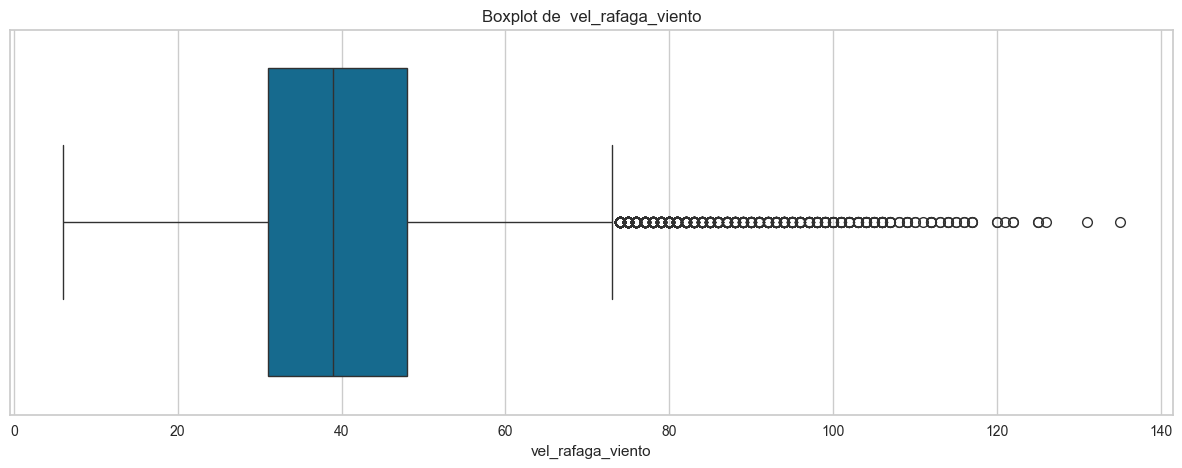

In [27]:
plt.figure(figsize=(15,5))

sns.boxplot(data=X_train, x= 'vel_rafaga_viento')
plt.title(f"Boxplot de  vel_rafaga_viento")

plt.show()

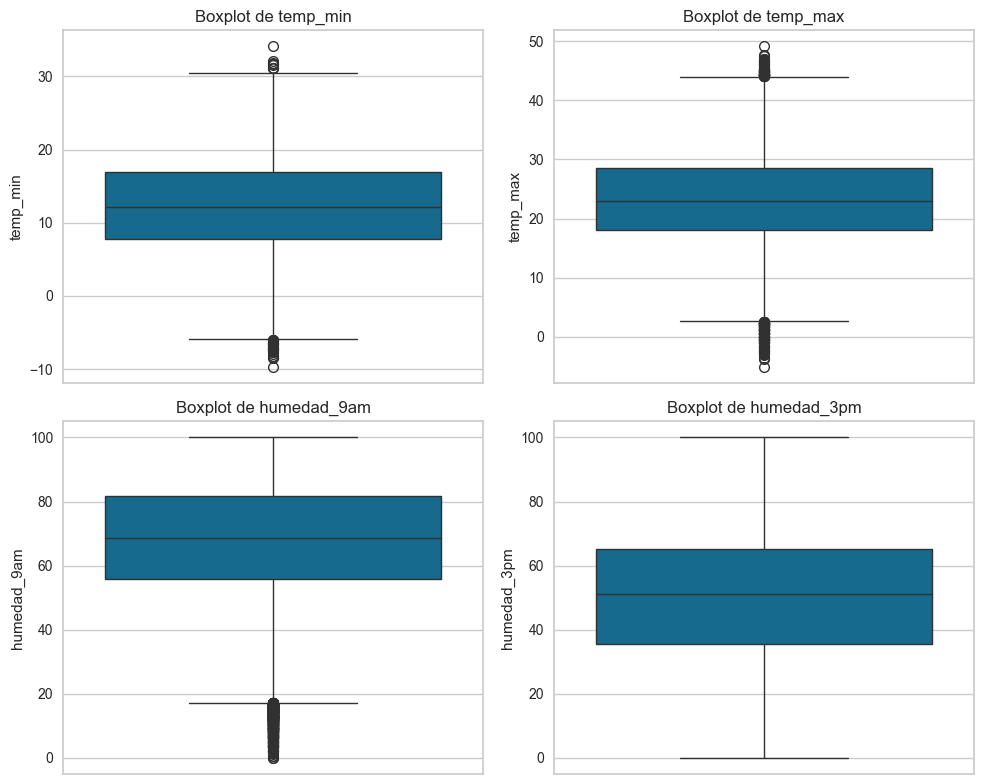

In [28]:
cols_num = ['temp_min', 'temp_max','humedad_9am', 'humedad_3pm']

plt.figure(figsize=(10,8))

for i, col in enumerate(cols_num):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=X_train, y=col)
    plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

Viendo los boxplots de temp_min y temp_max, vemos que presentan distribuciones bastante simétricas, reflejando la variabilidad climatica sin una presencia significativa de valores atipicos severos.

 Por otro lado, al analizar las variables de humedad, se evidencia un claro contraste a lo largo del día: la humedad_9am es mas alta y concentrada en valores elevados, presentando algunos outliers en el extremo inferior, mientras que hacia la tarde, humedad_3pm, la distribución se desplaza hacia valores menores.

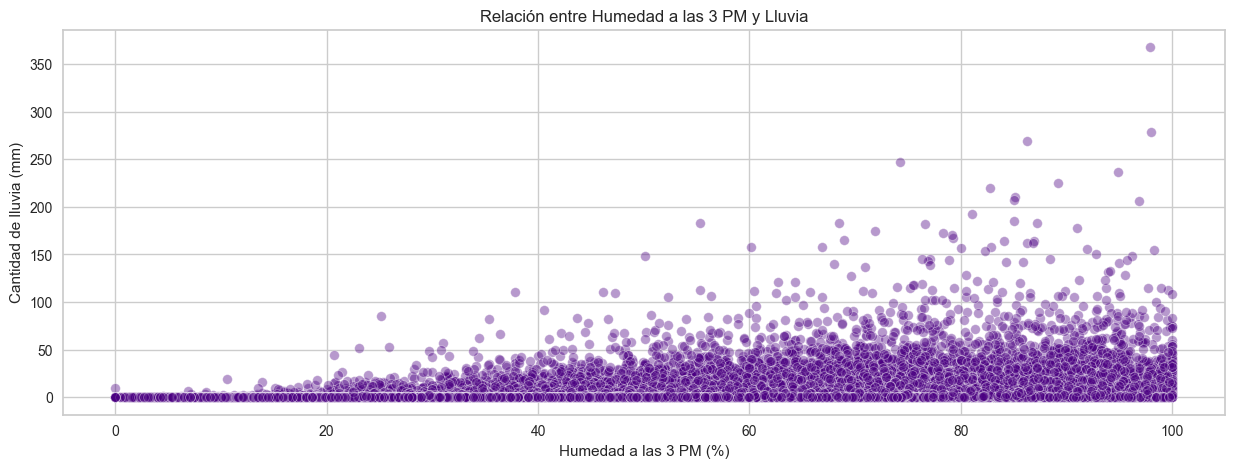

In [29]:
# SCATTERPLOT (humedad_3pm vs lluvia)

plt.figure(figsize=(15,5))
sns.scatterplot( data=X_train, x='humedad_3pm', y='lluvia', alpha=0.4, color='indigo')
plt.title('Relación entre Humedad a las 3 PM y Lluvia')
plt.xlabel('Humedad a las 3 PM (%)')
plt.ylabel('Cantidad de lluvia (mm)')
plt.show()

Se muestra una relación positiva entre la humedad a las 3 PM y la cantidad de lluvia. A medida que aumenta la humedad, también tienden a incrementarse las precipitaciones registradas. Sin embargo, la dispersión de los puntos indica que la relación no es completamente lineal y que intervienen otros factores climáticos en la ocurrencia de lluvia.

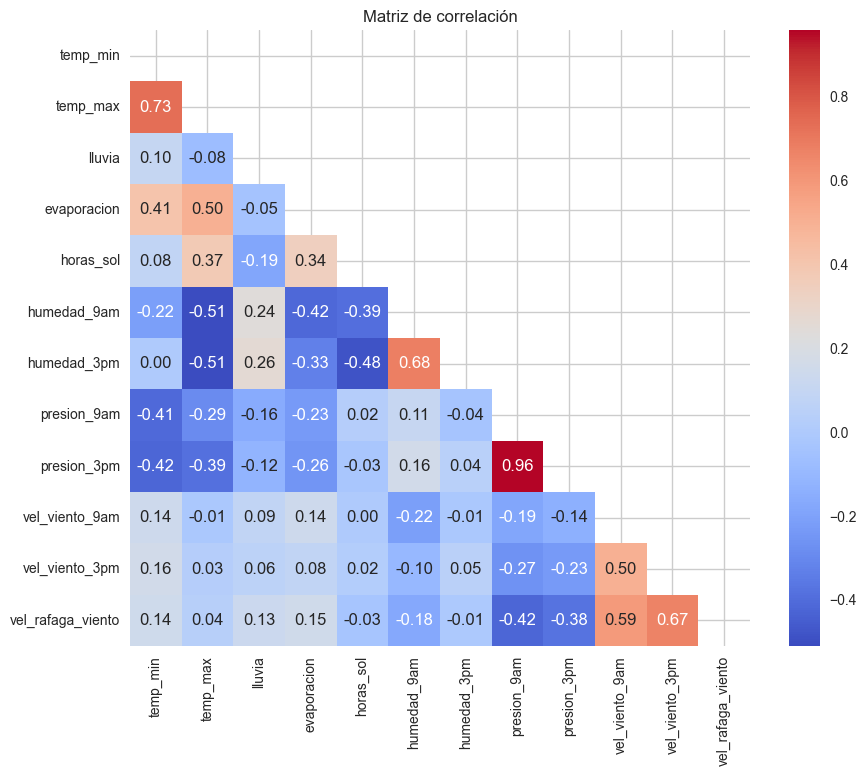

In [30]:
vars_corr = ['temp_min','temp_max','lluvia','evaporacion','horas_sol','humedad_9am','humedad_3pm',
             'presion_9am','presion_3pm','vel_viento_9am','vel_viento_3pm','vel_rafaga_viento']
corr = X_train[vars_corr].corr()

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Matriz de correlación')
plt.show()

### Codificación de variables categóricas:

In [31]:
# Lueve_hoy:
X_train['llovio_hoy'] = X_train['llovio_hoy'].map({'No':0, 'Yes':1})
X_test['llovio_hoy'] = X_test['llovio_hoy'].map({'No':0, 'Yes':1})

In [32]:
# Lueve_manana:
y_train = y_train.map({'No':0, 'Yes':1})
y_test =  y_test.map({'No':0, 'Yes':1})

In [33]:
# One-Hot Encoding:
cols_cat = ['ubicacion','dir_rafaga_viento','dir_viento_9am','dir_viento_3pm']

X_train = pd.get_dummies(X_train, columns=cols_cat, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_cat, drop_first=True)

#Alinear
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

Las variables categóricas fueron transformadas a variables numéricas para utilizarlas en el modelo de regresión logística. La variable 'llovio_hoy' fue codificada como binaria, mientras que las variables 'ubicacion','dir_rafaga_viento','dir_viento_9am'y'dir_viento_3pm' fueron transformadas con One-Hot Encoding.

### Estandarización/Escalado:

In [34]:
cols_num = ['temp_max', 'lluvia', 'evaporacion', 'horas_sol', 'humedad_3pm', 'presion_3pm', 'vel_viento_3pm', 'vel_rafaga_viento',
            'nubes_3pm','temp_3pm','humedad_9am','presion_9am','vel_viento_9am']

scaler = StandardScaler()
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])
X_test[cols_num] = scaler.transform(X_test[cols_num])

# 4) Regresión logística.

In [ ]:
# Inicializar y entrenar un modelo de regresión logística
modelo_log = LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
modelo_log.fit(X_train, y_train)

# Predicción
y_pred = modelo_log.predict(X_test)

# Probabilidad
y_prob = modelo_log.predict_proba(X_test)[:,1]

In [36]:
# Reporte de métricas
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.93      0.81      0.86     18976
           1       0.54      0.78      0.64      5376

    accuracy                           0.80     24352
   macro avg       0.73      0.80      0.75     24352
weighted avg       0.84      0.80      0.81     24352



In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.8019464520367937
Precision: 0.5351111111111111
Recall: 0.7838541666666666
F1-score: 0.636027469624934


Accuracy (0.80): El modelo acertó el 85% de todas sus predicciones

Precision (0.53): El modelo tiene un 53% de acierto y un 47% de falsas alarmas.

Recall (0.78): De todos los dias en los q llovio, el modelo fue capaz de detectar el 78%. 

F1-score (0.63): Es el balance general entre la precisión y el recall.

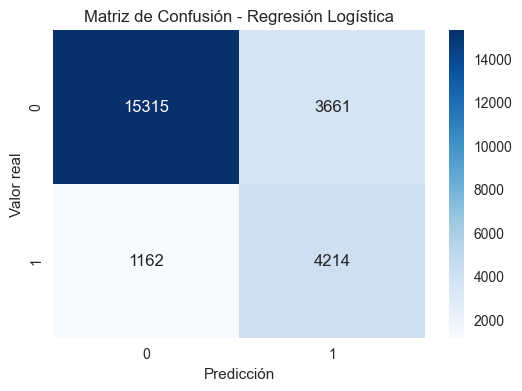

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

Falso negativo y falso positivo:

In [39]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 15315
False Positives: 3661
False Negatives: 1162
True Positives: 4214


Falso positivo (FP): El modelo predice lluvia para el día siguiente, pero en realidad no llueve.

Falso negativo (FN):El modelo predice que no lloverá, pero finalmente sí llueve.

El modelo logra identificar correctamente muchos dias sin lluvia(15315) y tambien una buena cantidad de dias lluviosos(4214).

Sin embargo, todavía comete algunos errores: en ciertos casos predice lluvia cuando finalmente no llueve (falsos positivos), y en otros no logra anticipar lluvias reales (falsos negativos).

In [40]:
# Probabilidades
y_prob = modelo_log.predict_proba(X_test)[:,1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Área bajo la curva
roc_auc = auc(fpr, tpr)

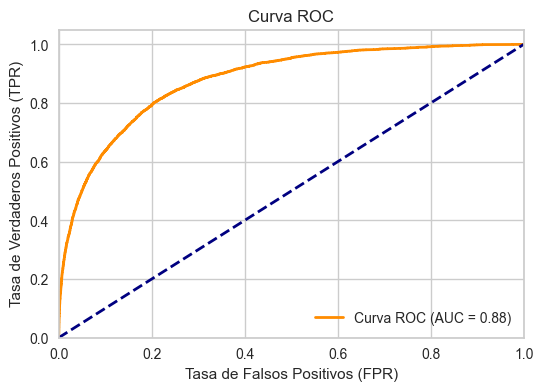

In [41]:
# Grafico la curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

La regresión logística alcanza un AUC cercano a 0.88, mostrando una muy buena capacidad para diferenciar días lluviosos de días sin lluvia.

In [42]:
roc_auc

0.8790038925265248

In [43]:
fpr, tpr, thresholds

(array([0.       , 0.       , 0.       , ..., 0.9771817, 0.9771817,
        1.       ]),
 array([0.00000000e+00, 1.86011905e-04, 8.74255952e-03, ...,
        9.99813988e-01, 1.00000000e+00, 1.00000000e+00]),
 array([       inf, 0.99974877, 0.99707208, ..., 0.01618217, 0.01617716,
        0.00258938]))

### Mejor Umbral

El umbral (threshold) representa el valor de probabilidad a partir del cual el modelo clasifica un caso como positivo (lluvia). Por defecto suele utilizarse 0.5, es decir, si la probabilidad predicha es mayor o igual a 50%, el modelo predice lluvia.

Sin embargo, 0.5 no siempre es el mejor umbral. El valor óptimo depende del problema y del equilibrio deseado entre precisión y recall. En problemas meteorológicos suele ser importante reducir los falsos negativos, ya que no predecir una lluvia real puede generar mayores consecuencias.

In [44]:
#UMBRAL
thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0
best_f1 = 0

for t in thresholds:

    y_pred_t = (y_prob >= t).astype(int)

    score = f1_score(y_test, y_pred_t)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Mejor umbral:", best_threshold)
print("Mejor F1-score:", best_f1)

Mejor umbral: 0.6500000000000001
Mejor F1-score: 0.6426104344664606


Se evaluaron distintos valores de threshold (umbral) para determinar cuál ofrecía el mejor equilibrio entre precisión y recall utilizando el F1-score como criterio de evaluación.

El mejor resultado se obtuvo con un umbral de 0.60, alcanzando un F1-score de aproximadamente 0.64. Esto indica que el modelo logra un mejor equilibrio entre la detección de días lluviosos y la reducción de falsas alarmas cuando se utiliza un umbral superior al valor por defecto de 0.5.

Concluimos que la selección del umbral tiene un impacto significativo en el desempeño del modelo y para este conjunto de datos, un umbral de 0.60 permite obtener el mejor compromiso entre precisión y recall según la métrica F1-score.

# 5)  Implementación del modelo base (Dummy Classifier).

In [45]:
# Inicializar y entrenar un modelo
modelo_base = DummyClassifier(strategy="most_frequent")
modelo_base.fit(X_train, y_train)

# Predicción
y_pred_base = modelo_base.predict(X_test)

# Probabilidad:
y_probs_base = modelo_base.predict_proba(X_test)[:, 1]

In [47]:
# Reporte de métricas
print("--- Reporte de Métricas ---")
print(classification_report(y_test, y_pred_base))

--- Reporte de Métricas ---
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     18976
           1       0.00      0.00      0.00      5376

    accuracy                           0.78     24352
   macro avg       0.39      0.50      0.44     24352
weighted avg       0.61      0.78      0.68     24352



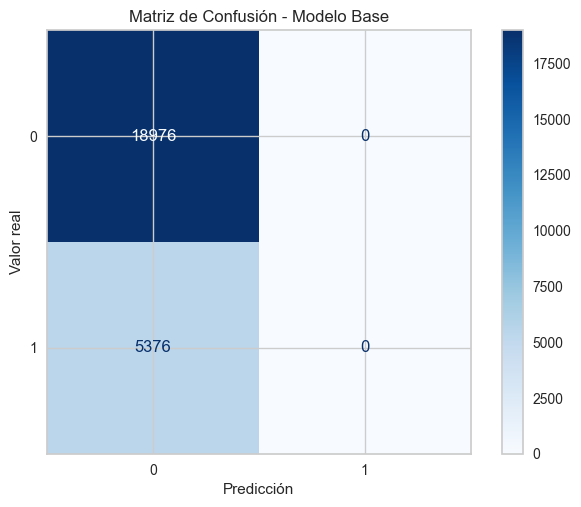

In [49]:
ConfusionMatrixDisplay.from_estimator(modelo_base, X_test, y_test, cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title('Matriz de Confusión - Modelo Base')
plt.show()

Falso negativo y falso positivo:

In [50]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_base).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 18976
False Positives: 0
False Negatives: 5376
True Positives: 0


El modelo base logró identificar correctamente los días sin lluvia, pero no pudo detectar ningún día lluvioso. Esto pasa porque siempre predice la clase más frecuente (‘No lluvia’), por lo que no aprende realmente patrones del clima y funciona solo como referencia para comparar con modelos más avanzados.

In [51]:
# Probabilidades
y_prob_base = modelo_base.predict_proba(X_test)[:,1]

# Curva ROC
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)

# Área bajo la curva
auc_base = auc(fpr_base, tpr_base)

print("AUC modelo base:", auc_base)

AUC modelo base: 0.5


Que el AUC del modelo base sea 0.5 refleja que el modelo no tiene ninguna capacidad para discriminar o separar las clases. Al predecir siempre de forma automatica la clase mas frecuente, su tasa de aciertos es equivalente a adivinar el clima mediante el azar.

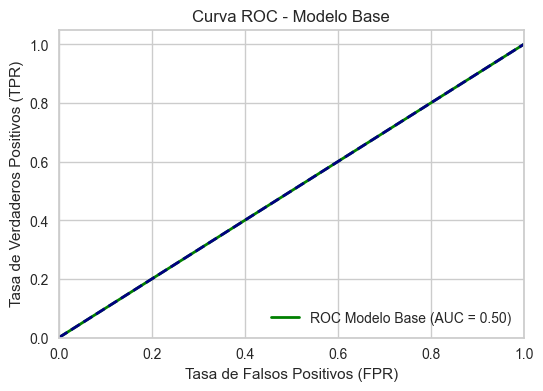

In [52]:
# Curva ROC - Modelo Base
plt.figure(figsize=(6, 4))
plt.plot(fpr_base, tpr_base, color='green', lw=2, label='ROC Modelo Base (AUC = %0.2f)' % auc_base)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo Base')
plt.legend(loc="lower right")
plt.show()

La regresión logística supera ampliamente al modelo base, demostrando capacidad para aprender patrones climáticos relevantes y realizar predicciones significativamente mejores que un clasificador aleatorio o trivial.

Probamos distintos thresholds solamente en la regresión logística, porque el modelo base básicamente siempre predice la opción más común y no aporta probabilidades útiles para analizar distintos umbrales.

**¿El modelo logró un buen fitting?**

Consideramos que el modelo logró un buen fitting, ya que obtuvo métricas significativamente superiores al modelo base. La regresión logística alcanzó un AUC cercano a 0.88, mostrando una buena capacidad para distinguir entre días con lluvia y sin lluvia.

# Entrega 2:

# 6) Optimización de párametros.

In [53]:
param_grid = {'penalty': ['l1', 'l2'],
              'C': [0.01, 0.1, 1, 10]}

cv_strat = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

grid = GridSearchCV(LogisticRegression(solver='liblinear',max_iter=1000,random_state=42),
    param_grid=param_grid,scoring='f1',cv=cv_strat,n_jobs=-1)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 10, 'penalty': 'l2'}
0.6181707077076851


Para optimizar los hiperparámetros ultilizamos Grid Search con validación cruzada estratificada de 5 folds. 

La mejor combinación encontrada fue penalty = 'l2' y C = 10, obteniendo un F1-score promedio de 0,618. El modelo logra su mejor desempeño utilizando regularización L2 y una penalización baja, ya que el valor de C = 10 reduce el efecto de la regularización y permite que el modelo se ajuste mejor a los datos.

La optimización de hiperparámetros permitió identificar una configuración que mejora el equilibrio entre precisión y recall, alcanzando el mejor desempeño observado durante el proceso de validación cruzada.

In [70]:
# Modelo optimizado
modelo_final = LogisticRegression(C=10,penalty='l2',solver='liblinear',max_iter=1000,random_state=42)

modelo_final.fit(X_train, y_train)

LogisticRegression(C=10, max_iter=1000, random_state=42, solver='liblinear')

In [71]:
# Predicción
y_pred = modelo_final.predict(X_test)

# Probabilidad:
y_prob = modelo_final.predict_proba(X_test)[:,1]

# 7) SHAP.

In [72]:
scaler_shap = StandardScaler()

# Escalamos y convertimos  a DataFrames de Pandas
X_train_scaled = pd.DataFrame(scaler_shap.fit_transform(X_train),columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler_shap.transform(X_test),columns=X_train.columns)

In [ ]:
# Inicializamos el LinearExplainer
explainer = shap.LinearExplainer(modelo_final, X_train_scaled)

# Valores SHAP
shap_values = explainer.shap_values(X_test_scaled)

In [74]:
index = 0

## Gráficas :

Globales:

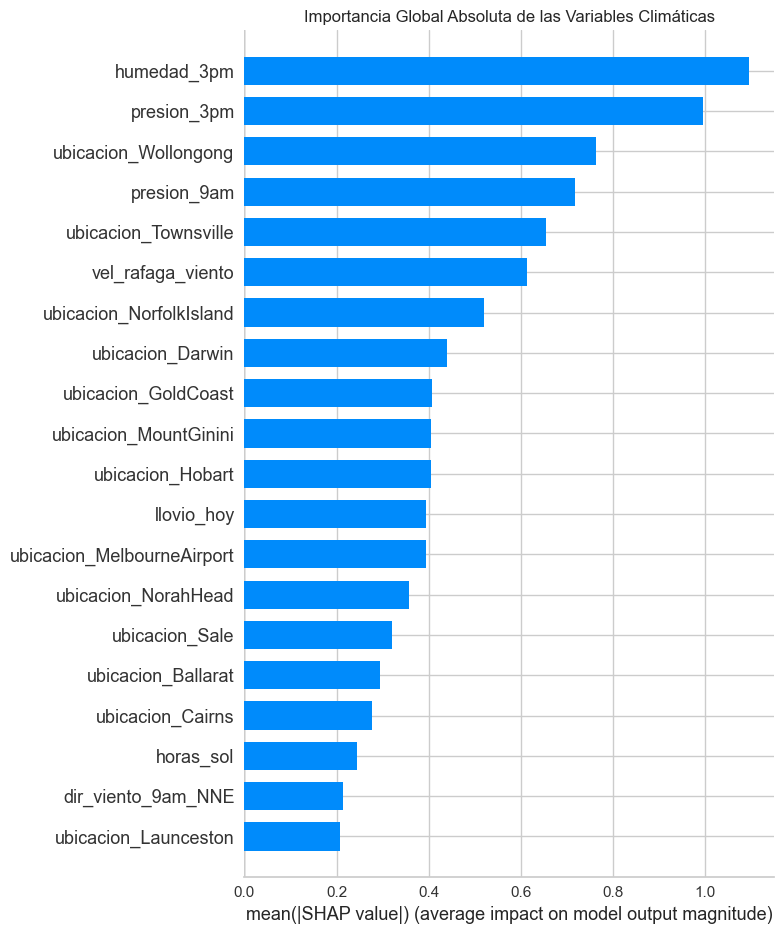

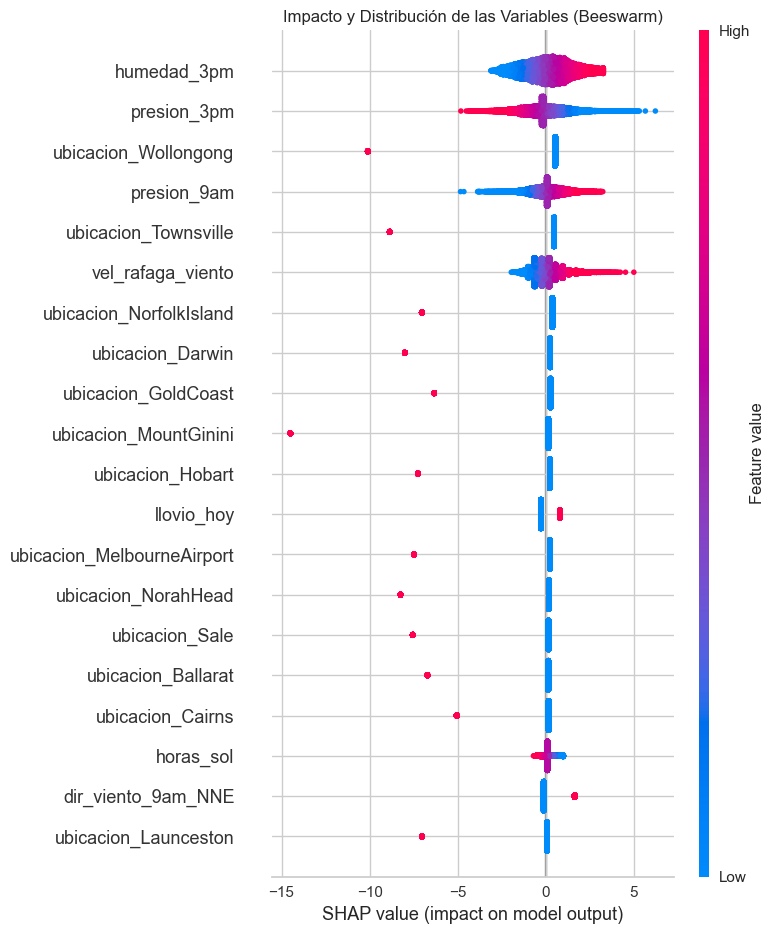

In [100]:
# Gráfica 1: Importancia de características en barras
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.title("Importancia Global Absoluta de las Variables Climáticas")
plt.tight_layout()
plt.show()

# Gráfica 2: Gráfico de enjambre (Beeswarm) para ver la direccionalidad
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title("Impacto y Distribución de las Variables (Beeswarm)")
plt.tight_layout()
plt.show()

**Análisis global**

Con el gráfico de importancia, se observa que las variables con mayor influencia sobre las predicciones son 'humedad_3pm' y 'presion_3pm', seguidas por 'ubicacion_Wollongong', 'presion_9am', 'ubicacion_Townsville' y 'vel_rafaga_viento'. Estas variables  son las que más contribuyen a las decisiones del modelo.

Y variables como 'ubicacion_Launceston', 'dir_viento_9am_NNE', 'horas_sol' y algunas ubicaciones muestran una influencia considerablemente menor sobre las predicciones, por lo que su aporte al modelo resulta más limitado.

El gráfico Beeswarm muestra no solo la importancia de cada variable, sino también la dirección de su efecto. Se observa que los valores elevados de 'humedad_3pm' tienden a incrementar la probabilidad de lluvia, mientras que determinados valores de presión atmosférica contribuyen a aumentar o disminuir dicha probabilidad según el caso. Esto confirma que las variables relacionadas con la humedad y la presión son factores determinantes para la predicción de lluvia.

Locales:

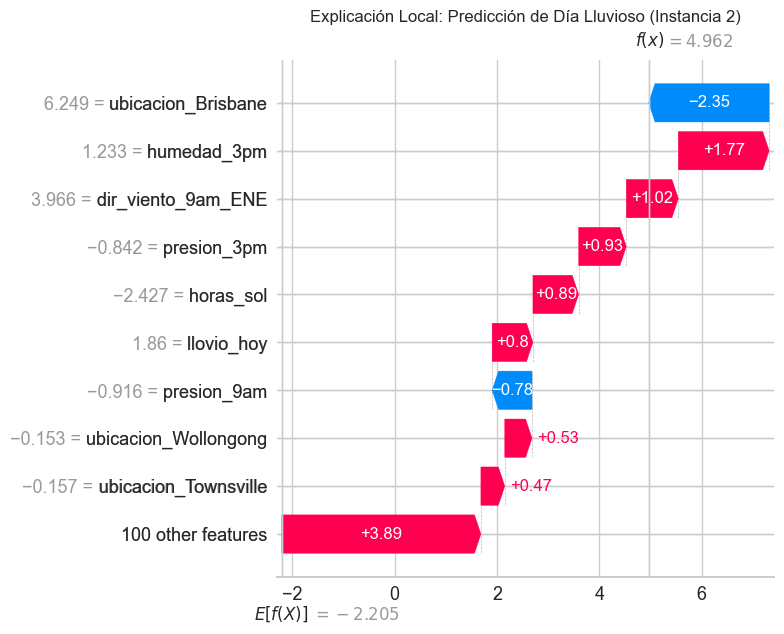

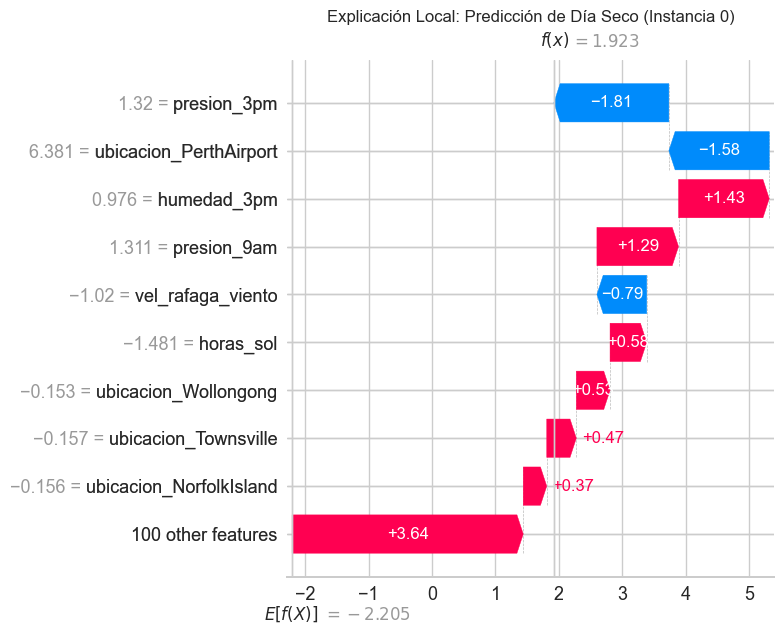

In [101]:
# Buscamos índices reales para mostrar casos particulares de lluvia o no lluvia usando y_test
ind_lluvia = np.where(y_test.values == 1)[0][0]
ind_no_lluvia = np.where(y_test.values == 0)[0][0]

explanation = shap.Explanation(values=shap_values[ind_lluvia],base_values=explainer.expected_value,data=X_test_scaled.iloc[ind_lluvia],
    feature_names=X_test_scaled.columns)

explanation2 = shap.Explanation(values=shap_values[ind_no_lluvia],base_values=explainer.expected_value,data=X_test_scaled.iloc[ind_no_lluvia],
    feature_names=X_test_scaled.columns)

# Gráfica 1: Caso de Día Lluvioso
plt.figure(figsize=(8, 4))
shap.plots.waterfall(explanation, show=False)
plt.title(f"Explicación Local: Predicción de Día Lluvioso (Instancia {ind_lluvia})")
plt.tight_layout()
plt.show()

# Gráfica 2: Caso de Día Seco
plt.figure(figsize=(8, 4))
shap.plots.waterfall(explanation2, show=False)
plt.title(f"Explicación Local: Predicción de Día Seco (Instancia {ind_no_lluvia})")
plt.tight_layout()
plt.show()

**Análisis local**

Analizamos dos observaciones mediante gráficos Waterfall: un día clasificado como lluvioso y otro como día seco.

En la predicción correspondiente del día lluvioso, las variables que más influyeron en la clasificación fueron humedad_3pm, dirección del viento a las 9 AM (ENE), presión a las 3 PM y horas de sol, cuyos valores contribuyeron significativamente a aumentar la probabilidad de lluvia.

Y en la predicción del día seco, variables como presion_3pm, determinadas ubicaciones geográficas y la humedad_3pm tuvieron mas importancia en la decisión del modelo, algunas actuaron reduciendo la probabilidad de lluvia y otras aumentándola.

Los resultados obtenidos con SHAP muestran que las variables meteorológicas comos la humedad, la presión atmosférica, la velocidad y dirección del viento, son las más relevantes para la predicción de lluvia. Además, ciertas ubicaciones geográficas presentan una influencia considerable, lo que sugiere que las características climáticas propias de cada región también afectan las predicciones del modelo.


# 8) Modelo de AutoML con Pycaret.

In [104]:
# Creamos el DataFrame unificado 
df_train_auto = pd.DataFrame(X_train, columns=X_train.columns)
df_train_auto['RainTomorrow'] = y_train.values

# Inicializamos el entorno de PyCaret
clasif = setup(data=df_train_auto,target='RainTomorrow',session_id=42)

# Comparamos los modelos y los ordenamos por el F1-Score
mejor_modelo = compare_models(fold=5, sort='F1')
print(mejor_modelo)

,Description,Value
0,Session id,42
1,Target,RainTomorrow
2,Target type,Binary
3,Original data shape,"(97405, 110)"
4,Transformed data shape,"(97405, 110)"
5,Transformed train set shape,"(68183, 110)"
6,Transformed test set shape,"(29222, 110)"
7,Numeric features,18
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8622,0.8919,0.5532,0.7573,0.6393,0.5567,0.5672,1.0740
lda,Linear Discriminant Analysis,0.8537,0.8765,0.5422,0.7256,0.6206,0.5323,0.5410,1.0300
lr,Logistic Regression,0.8549,0.8787,0.5321,0.7378,0.6182,0.5316,0.5424,8.3640
svm,SVM - Linear Kernel,0.8409,0.8729,0.5862,0.6830,0.6149,0.5175,0.5301,1.3420
gbc,Gradient Boosting Classifier,0.8555,0.8798,0.5178,0.7503,0.6127,0.5276,0.5413,7.8440
rf,Random Forest Classifier,0.8577,0.8855,0.5002,0.7754,0.6081,0.5261,0.5449,4.7760
ada,Ada Boost Classifier,0.8493,0.8686,0.5162,0.7222,0.6020,0.5123,0.5233,2.1140
et,Extra Trees Classifier,0.8571,0.8861,0.4821,0.7883,0.5983,0.5174,0.5406,6.5580
ridge,Ridge Classifier,0.8524,0.8765,0.4810,0.7629,0.5900,0.5056,0.5256,0.2220
knn,K Neighbors Classifier,0.8328,0.8115,0.4514,0.6839,0.5438,0.4467,0.4611,6.6600


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


El modelo seleccionado automáticamente por PyCaret fue Light Gradient Boosting Machine (LightGBM), obteniendo un Accuracy de 0,8622, un AUC de 0,8919 y un F1-score de 0,6393. Estos resultados fueron superiores a los obtenidos por la Regresión Logística optimizada mediante Grid Search, la cual alcanzó un Accuracy de 0,8549, un AUC de 0,8787 y un F1-score de 0,6182.

Aunque LightGBM presenta un mejor rendimiento, la Regresión Logística continúa siendo más fácil de interpretar y analizar, especialmente cuando se complementa con herramientas de explicabilidad como SHAP.